# Result and Analysis

### Styling tweaks

In [4]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")
base_colors = ["#895798", "#beaed4", "#fdc086", "#386cb0", "#f0027f", "#bf5b17"]
plt.rcParams.update({
    "axes.facecolor": "#0f1115",
    "figure.facecolor": "#0a0c10",
    "axes.edgecolor": "#444",
    "grid.color": "#333",
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.4,
    "axes.prop_cycle": plt.cycler(color=base_colors),
    "font.size": 11,
    "axes.titleweight": "bold",
})


## Experiment Result Fixed Depth

### Performance vs. scale

exp1
    scale  epoch_time_s  ms_per_step  val_loss  val_dice
0    0.2          91.0        362.0   0.19100   0.82240
1    0.3          92.5        370.0   0.19600   0.81220
2    0.4          92.0        369.0   0.18780   0.82510
3    0.5          87.0        260.0   0.18710   0.82230
4    0.6          89.0        177.0   0.19180   0.81000
5    0.7         104.0        104.0   0.26150   0.73995
6    0.8         123.0         61.5   0.61885   0.32260
7    0.9         125.0         62.0   0.53090   0.39510
exp2
    scale  epoch_time_s  ms_per_step  val_loss  val_dice
0    0.2          89.0        358.0   0.39960   0.57930
1    0.3          88.0        353.0   0.28640   0.70970
2    0.4          89.0        356.0   0.22540   0.77610
3    0.5          87.0        261.0   0.23590   0.76280
4    0.6          89.0        178.0   0.18820   0.81740
5    0.7         133.0        133.0   0.21140   0.76900
6    0.8         201.5        100.5   0.78935   0.18665


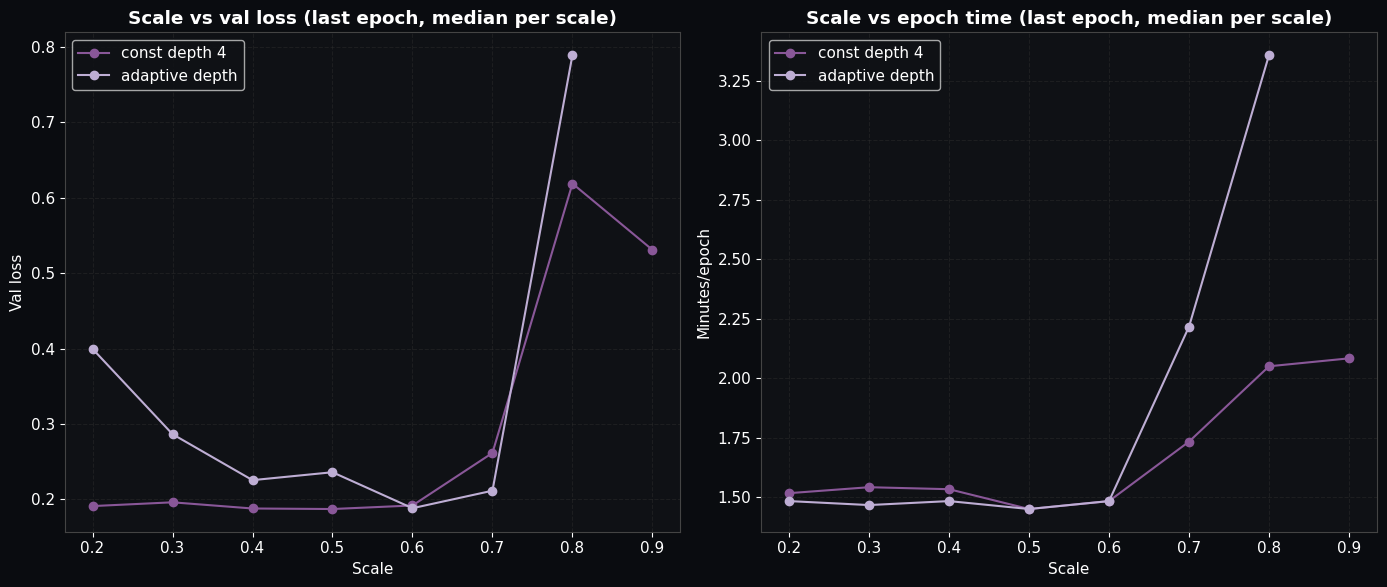

In [6]:
from pathlib import Path
import re, pandas as pd
import matplotlib.pyplot as plt

# regex for epoch lines
epoch_re = re.compile(
    r"\d+/\d+\s*-\s*(\d+)s\s*-\s*([\d.]+)ms/step\s*-\s*dice:\s*([\d.]+)\s*-\s*iou:\s*([\d.]+)\s*-\s*loss:\s*([\d.]+)\s*-\s*val_dice:\s*([\d.]+)\s*-\s*val_iou:\s*([\d.]+)\s*-\s*val_loss:\s*([\d.]+)"
)

def parse_last_epoch(log_path):
    last = None
    with open(log_path) as f:
        for line in f:
            m = epoch_re.search(line)
            if m:
                sec, ms_step, dice, iou, loss, v_dice, v_iou, v_loss = m.groups()
                last = {
                    "epoch_time_s": float(sec),
                    "ms_per_step": float(ms_step),
                    "val_loss": float(v_loss),
                    "val_dice": float(v_dice),
                }
    return last

def aggregate_experiment(root):
    rows = []
    for lp in (root / "runs" / "logs").glob("**/train-*.log"):
        m_scale = re.search(r"scale([0-9.]+)", lp.as_posix())
        if not m_scale:
            continue
        scale = float(m_scale.group(1))
        rec = parse_last_epoch(lp)
        if rec:
            rows.append({"scale": scale, **rec})
    if not rows:
        return pd.DataFrame()
    # collapse multiple runs per scale
    return (
        pd.DataFrame(rows)
        .groupby("scale")
        .median()      # median to smooth outliers; switch to mean if you prefer
        .reset_index()
        .sort_values("scale")
    )

base = Path.cwd()
if not (base / "experiments").exists():
    base = base.parent

exp1 = aggregate_experiment(base / "experiments" / "experiment_1_constant_depth_4")
exp2 = aggregate_experiment(base / "experiments" / "experiment_2_adaptive_depth")

print("exp1\n", exp1)
print("exp2\n", exp2)

if not exp1.empty and not exp2.empty:
    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1)
    plt.plot(exp1["scale"], exp1["val_loss"], "o-", label="const depth 4")
    plt.plot(exp2["scale"], exp2["val_loss"], "o-", label="adaptive depth")
    plt.title("Scale vs val loss (last epoch, median per scale)")
    plt.xlabel("Scale"); plt.ylabel("Val loss"); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(exp1["scale"], exp1["epoch_time_s"]/60, "o-", label="const depth 4")
    plt.plot(exp2["scale"], exp2["epoch_time_s"]/60, "o-", label="adaptive depth")
    plt.title("Scale vs epoch time (last epoch, median per scale)")
    plt.xlabel("Scale"); plt.ylabel("Minutes/epoch"); plt.legend()

    plt.tight_layout(); plt.show()


exp1:
     scale  epoch_time_s  ms_per_step    dice     iou    loss  val_dice  \
13    0.2          91.0        362.0  0.8887  0.8142  0.1095    0.8224   
4     0.3          95.0        380.0  0.8697  0.7887  0.1292    0.7986   
5     0.3          90.0        360.0  0.8907  0.8168  0.1078    0.8258   
16    0.4          92.0        369.0  0.8922  0.8187  0.1061    0.8251   
15    0.5          87.0        260.0  0.8921  0.8190  0.1062    0.8223   
14    0.6          89.0        177.0  0.8909  0.8167  0.1080    0.8100   
6     0.7         103.0        103.0  0.8826  0.8058  0.1161    0.7351   
7     0.7         105.0        105.0  0.8857  0.8099  0.1129    0.7448   
0     0.8         127.0         63.0  0.8847  0.8095  0.1154    0.3375   
2     0.8         117.0         58.0  0.9194  0.8572  0.0778    0.2253   
1     0.8         136.0         68.0  0.8859  0.8116  0.1138    0.4196   
3     0.8         119.0         60.0  0.8831  0.8075  0.1169    0.3077   
9     0.9         125.0        

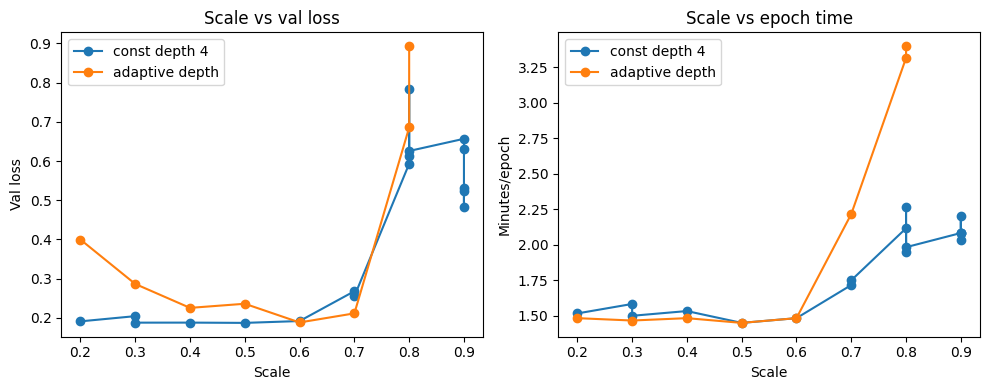

### Training Cost 

In [4]:
print(list((exp1_root / "runs" / "logs").glob("**/train/events.out.tfevents.*")))
print(list((exp2_root / "runs" / "logs").glob("**/train/events.out.tfevents.*")))


[PosixPath('/Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Segmenation/experiments/experiment_1_constant_depth_4/runs/logs/exp1_depth4_scale0.80_20251114-081752/exp1_depth4_scale0.80/train/events.out.tfevents.1763390055.cn48.1002451.0.v2'), PosixPath('/Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Segmenation/experiments/experiment_1_constant_depth_4/runs/logs/exp1_depth4_scale0.80_20251114-081752/exp1_depth4_scale0.80/train/events.out.tfevents.1763378133.cn47.943128.0.v2'), PosixPath('/Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Segmenation/experiments/experiment_1_constant_depth_4/runs/logs/exp1_depth4_scale0.80_20251114-081752/exp1_depth4_scale0.80/train/events.out.tfevents.1763104681.cn48.3648572.0.v2'), PosixPath('/Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Segmenation/experiments/experiment_1_constant_depth_4/runs/logs/exp1_depth4_scale0.80_20251114-081752/exp1_depth4_scale0.80/train/events.out.tfevents.

## Experiment Result Adpative Depth

### Performance vs. scale

Looking in: /Users/kunalnarwani/Desktop/Thesis/Kunal_Narwani_Thesis_git_2025/Super_resolution/experiments/experiment_2_adaptive_depth/evaluation
Available runs: ['exp1_depth3_scale0.80_eval', 'exp2_adaptive_depth_scale0.20_eval', 'exp2_adaptive_depth_scale0.30_eval', 'exp2_adaptive_depth_scale0.40_eval', 'exp2_adaptive_depth_scale0.50_eval', 'exp2_adaptive_depth_scale0.60_eval', 'exp2_adaptive_depth_scale0.70_eval']


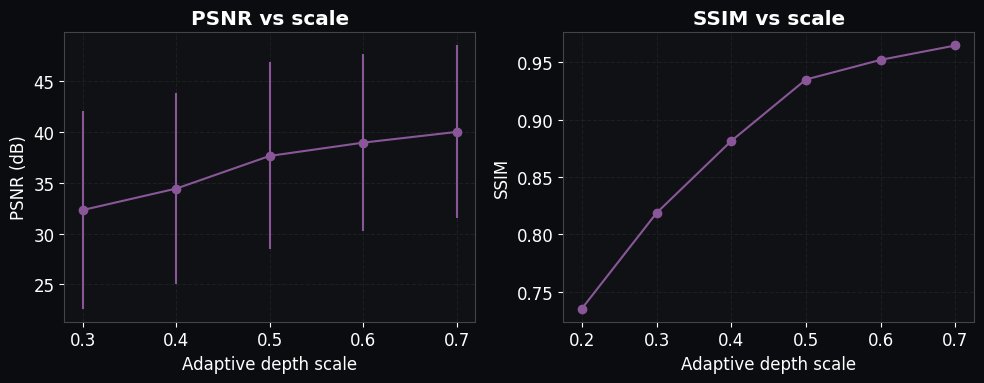

In [15]:
project_root = Path.cwd()
root = project_root / "experiments" / "experiment_2_adaptive_depth" / "evaluation"

# sanity-check the directory
print("Looking in:", root)
print("Available runs:", sorted([p.name for p in root.iterdir() if p.is_dir()]))

scales = ["0.20","0.30","0.40","0.50","0.60","0.70"]
metrics = []
for s in scales:
    eval_dir = root / f"exp2_adaptive_depth_scale{s}_eval"
    with open(eval_dir / "metrics.json") as f:
        m = json.load(f)
    metrics.append({
        "scale": float(s),
        "psnr": m.get("psnr_mean", np.nan),
        "ssim": m.get("ssim_mean", np.nan),
        "mse": m.get("mse_mean", np.nan),
        "psnr_std": m.get("psnr_std", np.nan),
    })

scales_f = [m["scale"] for m in metrics]
psnr = [m["psnr"] for m in metrics]
ssim = [m["ssim"] for m in metrics]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.errorbar(scales_f, psnr, yerr=[m["psnr_std"] for m in metrics], marker="o")
plt.title("PSNR vs scale"); plt.xlabel("Adaptive depth scale"); plt.ylabel("PSNR (dB)")
plt.subplot(1,2,2)
plt.plot(scales_f, ssim, marker="o")
plt.title("SSIM vs scale"); plt.xlabel("Adaptive depth scale"); plt.ylabel("SSIM")
plt.tight_layout(); plt.show()


### Training cost 

   scale  ms_per_step  epoch_duration_s
2    0.2        381.0             206.0
4    0.3        511.0             276.0
5    0.4        498.0             359.0
1    0.5        445.0             481.0
0    0.6        557.0             802.0
6    0.7        895.0            1933.0
3    0.8        977.0            4221.0


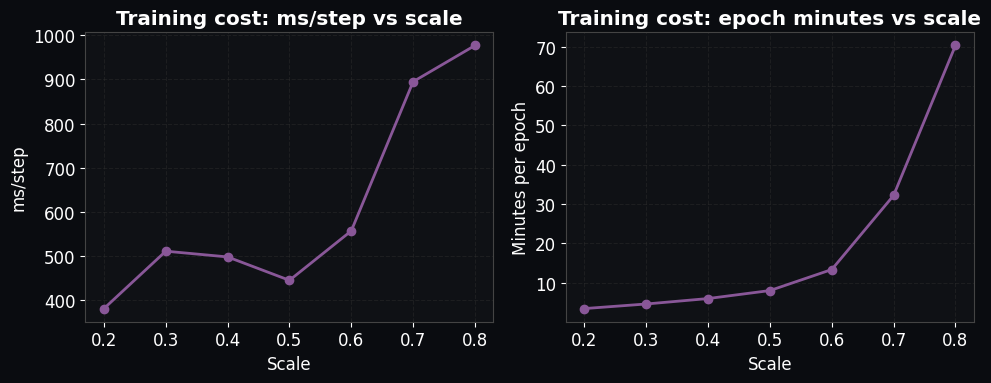

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

project_root = Path.cwd()
if not (project_root / "experiments").exists():
    project_root = project_root.parent

csv_root = project_root / "experiments" / "experiment_2_adaptive_depth" / "csv_logs"

rows = []
for csv_file in csv_root.glob("exp2_adaptive_depth_scale*/epoch_metrics.csv"):
    m = re.search(r"scale([0-9.]+)", csv_file.parent.name)
    if not m:
        continue
    df = pd.read_csv(csv_file)
    rows.append({
        "scale": float(m.group(1)),
        "ms_per_step": df["ms_per_step"].iloc[-1],
        "epoch_duration_s": df["duration_s"].iloc[-1],
    })

time_df = pd.DataFrame(rows).sort_values("scale")
print(time_df)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(time_df["scale"], time_df["ms_per_step"], marker="o", linewidth=2)
plt.title("Training cost: ms/step vs scale")
plt.xlabel("Scale"); plt.ylabel("ms/step")

plt.subplot(1,2,2)
plt.plot(time_df["scale"], time_df["epoch_duration_s"]/60, marker="o", linewidth=2)
plt.title("Training cost: epoch minutes vs scale")
plt.xlabel("Scale"); plt.ylabel("Minutes per epoch")

plt.tight_layout(); plt.show()
